In [46]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [47]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. PLTR - Palantir

In [48]:
# ticker
ticker = 'PLTR'

# Create a Ticker object
pltr = yf.Ticker(ticker)

In [49]:
data_pltr = pltr.history(start="2024-02-15", end="2024-11-20", interval="1d")

In [50]:
print(data_pltr.head())

                                Open       High        Low      Close  \
Date                                                                    
2024-02-15 00:00:00-05:00  25.040001  25.459999  24.709999  25.410000   
2024-02-16 00:00:00-05:00  24.959999  25.495001  24.389999  24.440001   
2024-02-20 00:00:00-05:00  23.840000  24.000000  22.715000  23.400000   
2024-02-21 00:00:00-05:00  22.299999  22.930000  22.290001  22.740000   
2024-02-22 00:00:00-05:00  23.770000  23.950001  23.049999  23.590000   

                             Volume  Dividends  Stock Splits  
Date                                                          
2024-02-15 00:00:00-05:00  70544300        0.0           0.0  
2024-02-16 00:00:00-05:00  65498200        0.0           0.0  
2024-02-20 00:00:00-05:00  93374300        0.0           0.0  
2024-02-21 00:00:00-05:00  59628300        0.0           0.0  
2024-02-22 00:00:00-05:00  64458200        0.0           0.0  


### Extracting closing price columns

In [51]:
# Extract only the closing price column
close_prices = data_pltr["Close"]

df_pltr_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
df_pltr_close.reset_index(drop=True, inplace=True)

print(df_pltr_close.head())

                       Date      Close
0 2024-02-15 00:00:00-05:00  25.410000
1 2024-02-16 00:00:00-05:00  24.440001
2 2024-02-20 00:00:00-05:00  23.400000
3 2024-02-21 00:00:00-05:00  22.740000
4 2024-02-22 00:00:00-05:00  23.590000


### CSV

In [52]:
df_pltr_close.to_csv("pltr_close_prices.csv", index=False)

In [53]:
df_pltr = pd.read_csv("pltr_close_prices.csv")
df_pltr.head()

,Date,Close
0,2024-02-15 00:00:00-05:00,25.410000
1,2024-02-16 00:00:00-05:00,24.440001
2,2024-02-20 00:00:00-05:00,23.400000
3,2024-02-21 00:00:00-05:00,22.740000
4,2024-02-22 00:00:00-05:00,23.590000


### Visualization

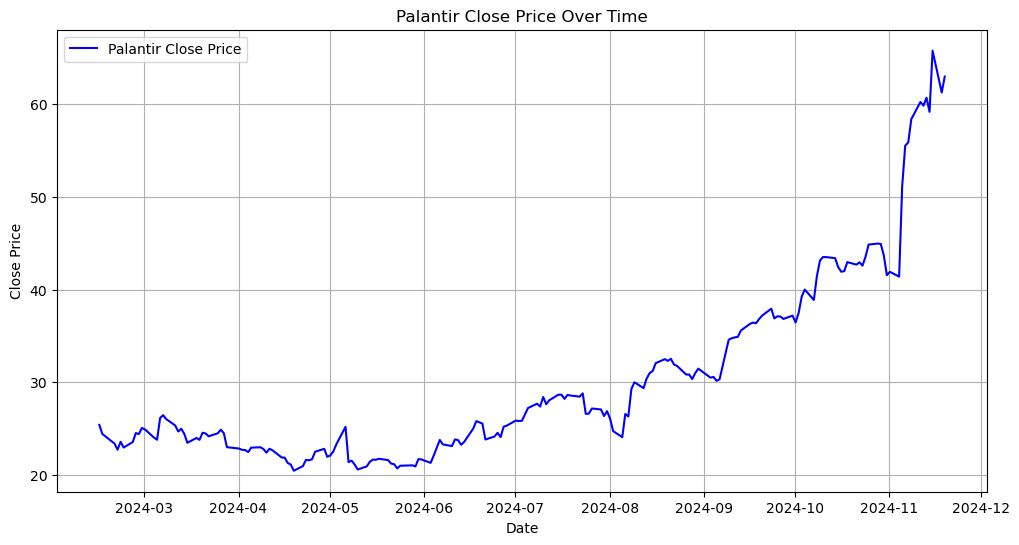

In [54]:
# Convert 'Date' column to datetime
df_pltr['Date'] = pd.to_datetime(df_pltr['Date'], utc=True).dt.tz_localize(None)

# Set 'Date' as the index (optional but makes plotting easier)
df_pltr.set_index('Date', inplace=True)

# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(df_pltr.index, df_pltr['Close'], color='blue', label='Palantir Close Price')
plt.title('Palantir Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.legend()
plt.show()


In [55]:
data_pltr.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,193.000000,193.000000,193.000000,193.000000,1.930000e+02,193.0,193.0
mean,30.017109,30.695757,29.429150,30.143679,5.532708e+07,0.0,0.0
std,9.721751,10.033708,9.477760,9.900985,4.175716e+07,0.0,0.0
min,20.600000,20.990000,20.330000,20.469999,1.843380e+07,0.0,0.0
25%,23.059999,23.719999,22.715000,23.129999,3.396900e+07,0.0,0.0
50%,26.040001,27.250000,25.750000,26.080000,4.441610e+07,0.0,0.0
75%,34.860001,35.400002,34.530998,34.910000,6.254290e+07,0.0,0.0
max,64.919998,66.000000,60.910000,65.769997,4.502905e+08,0.0,0.0


In [56]:
data_pltr.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 193 entries, 2024-02-15 00:00:00-05:00 to 2024-11-19 00:00:00-05:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          193 non-null    float64
 1   High          193 non-null    float64
 2   Low           193 non-null    float64
 3   Close         193 non-null    float64
 4   Volume        193 non-null    int64  
 5   Dividends     193 non-null    float64
 6   Stock Splits  193 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 12.1 KB


In [57]:
data_pltr.shape

(193, 7)

In [58]:
data_pltr.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [59]:
# Reset index
df_pltr.reset_index(inplace=True)

In [60]:
df_pltr['Date'] = pd.to_datetime(df_pltr['Date'], utc=True).dt.tz_localize(None)

## KPIs

### Completeness

In [61]:
print(f"The missing values in the dataset: {df_pltr['Close'].isnull().sum()}")

The missing values in the dataset: 0


No missing values were found, indicating high completeness.

### Latency

In [62]:
min_date = df_pltr["Date"].min()
max_date = df_pltr["Date"].max()

print(f"Minimum Date: {min_date}")
print(f"Maximum Date: {max_date}")

Minimum Date: 2024-02-15 05:00:00
Maximum Date: 2024-11-19 05:00:00


The data is sourced from Yahoo Finance and updated regularly, which means low latency.

### Accuracy

In [63]:
min_close_price = df_pltr["Close"].min()
max_close_price = df_pltr["Close"].max()

print(f"Minimum Close Price: {min_close_price}")
print(f"Maximum Close Price: {max_close_price}")

Minimum Close Price: 20.46999931335449
Maximum Close Price: 65.7699966430664


The values fall within a realistic range and come from a reliable source, indicating good accuracy.

### Consistency

In [64]:
print("Duplicates:", df_pltr.duplicated().sum())
print(df_pltr.dtypes)

Duplicates: 0
Date     datetime64[ns]
Close           float64
dtype: object


The dataset has consistent data types and no duplicate rows, which indicates good consistency.

# 2. SHOP - Shopify

In [65]:
# ticker
ticker = 'SHOP'

# Create a Ticker object
shop = yf.Ticker(ticker)

In [66]:
data_shop = shop.history(start="2023-03-10", end="2023-10-05", interval="1d")

In [67]:
print(data_shop.head())

                                Open       High        Low      Close  \
Date                                                                    
2023-03-10 00:00:00-05:00  42.139999  42.634998  40.520000  41.459999   
2023-03-13 00:00:00-04:00  40.520000  42.764999  39.790001  41.779999   
2023-03-14 00:00:00-04:00  42.959999  44.209999  42.860001  43.799999   
2023-03-15 00:00:00-04:00  42.630001  43.560001  42.090000  43.540001   
2023-03-16 00:00:00-04:00  43.490002  44.849998  42.020000  44.669998   

                             Volume  Dividends  Stock Splits  
Date                                                          
2023-03-10 00:00:00-05:00  22080900        0.0           0.0  
2023-03-13 00:00:00-04:00  18922300        0.0           0.0  
2023-03-14 00:00:00-04:00  16867700        0.0           0.0  
2023-03-15 00:00:00-04:00  17052200        0.0           0.0  
2023-03-16 00:00:00-04:00  15374500        0.0           0.0  


### Extracting closing price columns

In [68]:
# Extract only the closing price column
close_prices = data_shop["Close"]

df_shop_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
df_shop_close.reset_index(drop=True, inplace=True)

print(df_shop_close.head())

                       Date      Close
0 2023-03-10 00:00:00-05:00  41.459999
1 2023-03-13 00:00:00-04:00  41.779999
2 2023-03-14 00:00:00-04:00  43.799999
3 2023-03-15 00:00:00-04:00  43.540001
4 2023-03-16 00:00:00-04:00  44.669998


### CSV

In [69]:
df_shop_close.to_csv("shop_close_prices.csv", index=False)

In [70]:
df_shop = pd.read_csv("shop_close_prices.csv")
df_shop.head()

,Date,Close
0,2023-03-10 00:00:00-05:00,41.459999
1,2023-03-13 00:00:00-04:00,41.779999
2,2023-03-14 00:00:00-04:00,43.799999
3,2023-03-15 00:00:00-04:00,43.540001
4,2023-03-16 00:00:00-04:00,44.669998


### Visualization

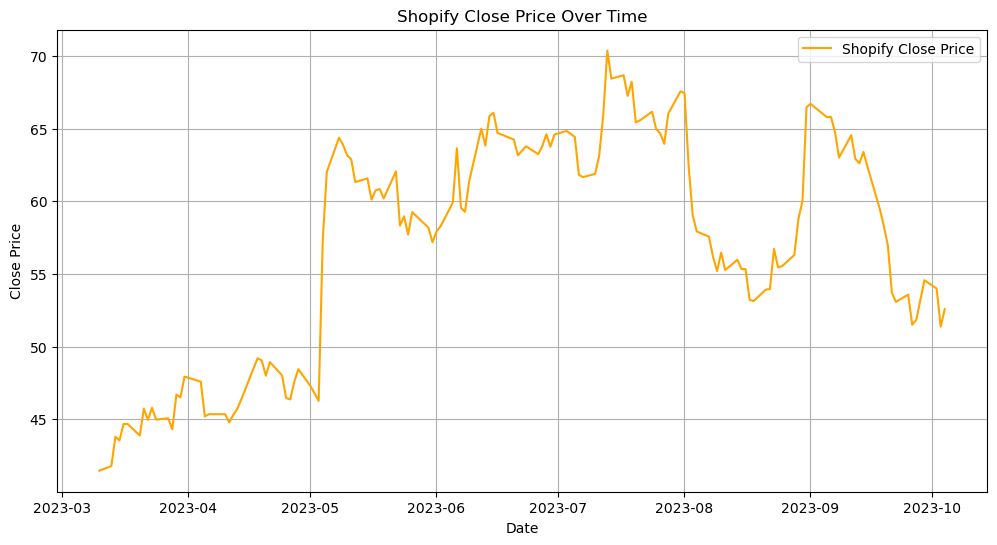

In [71]:
# Convert 'Date' column to datetime
df_shop['Date'] = pd.to_datetime(df_shop['Date'], utc=True).dt.tz_localize(None)

# Set 'Date' as the index (optional but makes plotting easier)
df_shop.set_index('Date', inplace=True)

# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(df_shop.index, df_shop['Close'], color='orange', label='Shopify Close Price')
plt.title('Shopify Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.legend()
plt.show()

In [72]:
data_shop.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,144.000000,144.000000,144.000000,144.000000,1.440000e+02,144.0,144.0
mean,56.921528,58.064923,55.867208,56.915625,1.347912e+07,0.0,0.0
std,7.783593,7.882923,7.614424,7.693327,8.620100e+06,0.0,0.0
min,40.520000,42.634998,39.790001,41.459999,6.531000e+06,0.0,0.0
25%,48.742498,49.441252,48.195001,49.022499,9.124225e+06,0.0,0.0
50%,58.375000,59.830000,57.225000,58.310001,1.149795e+07,0.0,0.0
75%,63.542500,64.821249,62.682501,63.684999,1.431918e+07,0.0,0.0
max,70.610001,71.430000,68.419998,70.370003,8.892730e+07,0.0,0.0


In [73]:
data_shop.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 2023-03-10 00:00:00-05:00 to 2023-10-04 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          144 non-null    float64
 1   High          144 non-null    float64
 2   Low           144 non-null    float64
 3   Close         144 non-null    float64
 4   Volume        144 non-null    int64  
 5   Dividends     144 non-null    float64
 6   Stock Splits  144 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 9.0 KB


In [74]:
data_shop.shape

(144, 7)

In [75]:
data_shop.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [76]:
# Reset index
df_shop.reset_index(inplace=True)

In [77]:
df_shop['Date'] = pd.to_datetime(df_shop['Date'], utc=True).dt.tz_localize(None)

## KPIs

### Completeness

In [78]:
print(f"The missing values in the dataset: {df_shop['Close'].isnull().sum()}")

The missing values in the dataset: 0


No missing values were found, indicating high completeness.

### Latency

In [79]:
min_date = df_shop["Date"].min()
max_date = df_shop["Date"].max()

print(f"Minimum Date: {min_date}")
print(f"Maximum Date: {max_date}")

Minimum Date: 2023-03-10 05:00:00
Maximum Date: 2023-10-04 04:00:00


The data is sourced from Yahoo Finance and updated regularly, which means low latency.

### Accuracy

In [80]:
min_close_price = df_shop["Close"].min()
max_close_price = df_shop["Close"].max()

print(f"Minimum Close Price: {min_close_price}")
print(f"Maximum Close Price: {max_close_price}")

Minimum Close Price: 41.459999084472656
Maximum Close Price: 70.37000274658203


The values fall within a realistic range and come from a reliable source, indicating good accuracy.

### Consistency

In [81]:
print("Duplicates:", df_shop.duplicated().sum())
print(df_shop.dtypes)

Duplicates: 0
Date     datetime64[ns]
Close           float64
dtype: object


The dataset has consistent data types and no duplicate rows, which indicates good consistency.

# 3. MRNA - Moderna

In [82]:
# ticker
ticker = 'MRNA'

# Create a Ticker object
mrna = yf.Ticker(ticker)

In [83]:
data_mrna = mrna.history(start="2022-01-10", end="2022-09-15", interval="1d")

In [84]:
print(data_mrna.head())

                                 Open        High         Low       Close  \
Date                                                                        
2022-01-10 00:00:00-05:00  211.369995  241.990005  207.500000  233.699997   
2022-01-11 00:00:00-05:00  226.000000  228.000000  220.279999  221.389999   
2022-01-12 00:00:00-05:00  220.479996  228.500000  218.759995  222.889999   
2022-01-13 00:00:00-05:00  219.559998  221.500000  209.580002  210.169998   
2022-01-14 00:00:00-05:00  204.009995  212.759995  200.080002  204.729996   

                             Volume  Dividends  Stock Splits  
Date                                                          
2022-01-10 00:00:00-05:00  17191500        0.0           0.0  
2022-01-11 00:00:00-05:00   7331200        0.0           0.0  
2022-01-12 00:00:00-05:00   5846600        0.0           0.0  
2022-01-13 00:00:00-05:00   7405700        0.0           0.0  
2022-01-14 00:00:00-05:00  10167500        0.0           0.0  


### Extracting closing price columns

In [85]:
# Extract only the closing price column
close_prices = data_mrna["Close"]

df_mrna_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
df_mrna_close.reset_index(drop=True, inplace=True)

print(df_mrna_close.head())

                       Date       Close
0 2022-01-10 00:00:00-05:00  233.699997
1 2022-01-11 00:00:00-05:00  221.389999
2 2022-01-12 00:00:00-05:00  222.889999
3 2022-01-13 00:00:00-05:00  210.169998
4 2022-01-14 00:00:00-05:00  204.729996


### CSV

In [86]:
df_mrna_close.to_csv("mrna_close_prices.csv", index=False)

In [87]:
df_mrna = pd.read_csv("mrna_close_prices.csv")
df_mrna.head()

,Date,Close
0,2022-01-10 00:00:00-05:00,233.699997
1,2022-01-11 00:00:00-05:00,221.389999
2,2022-01-12 00:00:00-05:00,222.889999
3,2022-01-13 00:00:00-05:00,210.169998
4,2022-01-14 00:00:00-05:00,204.729996


### Visualization

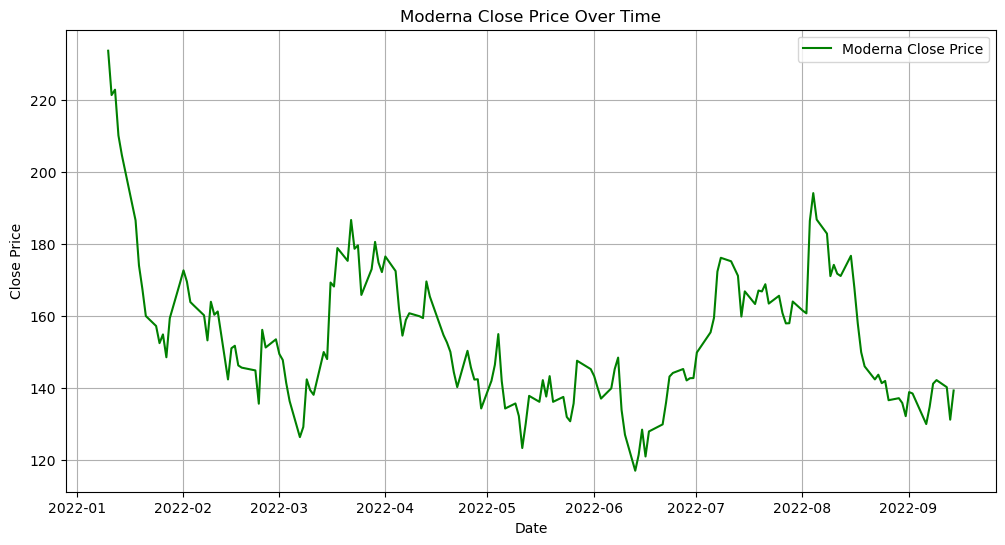

In [88]:
# Convert 'Date' column to datetime
df_mrna['Date'] = pd.to_datetime(df_mrna['Date'], utc=True).dt.tz_localize(None)

# Set 'Date' as the index (optional but makes plotting easier)
df_mrna.set_index('Date', inplace=True)

# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(df_mrna.index, df_mrna['Close'], color='green', label='Moderna Close Price')
plt.title('Moderna Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.legend()
plt.show()

In [89]:
data_mrna.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,171.000000,171.000000,171.000000,171.000000,1.710000e+02,171.0,171.0
mean,154.251818,159.599316,149.384445,154.343333,6.422703e+06,0.0,0.0
std,19.518477,20.099607,18.964995,19.563486,3.064042e+06,0.0,0.0
min,117.260002,123.150002,115.610001,117.129997,2.488500e+06,0.0,0.0
25%,140.199997,144.565002,136.167503,140.330002,4.459100e+06,0.0,0.0
50%,150.979996,156.190002,145.279999,150.410004,5.720000e+06,0.0,0.0
75%,166.879997,171.571999,161.014999,166.900002,7.368450e+06,0.0,0.0
max,226.000000,241.990005,220.279999,233.699997,2.284110e+07,0.0,0.0


In [90]:
data_mrna.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 171 entries, 2022-01-10 00:00:00-05:00 to 2022-09-14 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          171 non-null    float64
 1   High          171 non-null    float64
 2   Low           171 non-null    float64
 3   Close         171 non-null    float64
 4   Volume        171 non-null    int64  
 5   Dividends     171 non-null    float64
 6   Stock Splits  171 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 10.7 KB


In [91]:
data_mrna.shape

(171, 7)

In [92]:
data_mrna.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [94]:
# Reset index
df_mrna.reset_index(inplace=True)

In [95]:
df_mrna['Date'] = pd.to_datetime(df_mrna['Date'], utc=True).dt.tz_localize(None)

## KPIs

### Completeness

In [96]:
print(f"The missing values in the dataset: {df_mrna['Close'].isnull().sum()}")

The missing values in the dataset: 0


No missing values were found, indicating high completeness.

### Latency

In [97]:
min_date = df_mrna["Date"].min()
max_date = df_mrna["Date"].max()

print(f"Minimum Date: {min_date}")
print(f"Maximum Date: {max_date}")

Minimum Date: 2022-01-10 05:00:00
Maximum Date: 2022-09-14 04:00:00


The data is sourced from Yahoo Finance and represents historical daily prices, which is sufficient for analysis purposes.

### Accuracy

In [98]:
min_close_price = df_mrna["Close"].min()
max_close_price = df_mrna["Close"].max()

print(f"Minimum Close Price: {min_close_price}")
print(f"Maximum Close Price: {max_close_price}")

Minimum Close Price: 117.12999725341795
Maximum Close Price: 233.6999969482422


The values fall within a realistic range and come from a reliable source, indicating good accuracy.

### Consistency

In [99]:
print("Duplicates:", df_mrna.duplicated().sum())
print(df_mrna.dtypes)

Duplicates: 0
Date     datetime64[ns]
Close           float64
dtype: object


The dataset has consistent data types and no duplicate rows, which indicates good consistency.

# 4. UBER - Uber

In [100]:
# ticker
ticker = 'UBER'

# Create a Ticker object
uber = yf.Ticker(ticker)

In [101]:
data_uber = uber.history(start="2021-06-01", end="2022-02-01", interval="1d")

In [102]:
print(data_uber.head())

                                Open       High        Low      Close  \
Date                                                                    
2021-06-01 00:00:00-04:00  51.619999  51.660000  49.840000  50.980000   
2021-06-02 00:00:00-04:00  51.189999  51.410000  50.549999  50.790001   
2021-06-03 00:00:00-04:00  50.430000  50.500000  48.529999  48.700001   
2021-06-04 00:00:00-04:00  49.560001  50.220001  49.070000  50.180000   
2021-06-07 00:00:00-04:00  50.490002  51.220001  49.750000  50.759998   

                             Volume  Dividends  Stock Splits  
Date                                                          
2021-06-01 00:00:00-04:00  16583800        0.0           0.0  
2021-06-02 00:00:00-04:00  13484200        0.0           0.0  
2021-06-03 00:00:00-04:00  14712900        0.0           0.0  
2021-06-04 00:00:00-04:00  10409800        0.0           0.0  
2021-06-07 00:00:00-04:00  16466200        0.0           0.0  


### Extracting closing price columns

In [103]:
# Extract only the closing price column
close_prices = data_uber["Close"]

df_uber_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
df_uber_close.reset_index(drop=True, inplace=True)

print(df_uber_close.head())

                       Date      Close
0 2021-06-01 00:00:00-04:00  50.980000
1 2021-06-02 00:00:00-04:00  50.790001
2 2021-06-03 00:00:00-04:00  48.700001
3 2021-06-04 00:00:00-04:00  50.180000
4 2021-06-07 00:00:00-04:00  50.759998


### CSV

In [104]:
df_uber_close.to_csv("uber_close_prices.csv", index=False)

In [105]:
df_uber = pd.read_csv("uber_close_prices.csv")
df_uber.head()

,Date,Close
0,2021-06-01 00:00:00-04:00,50.980000
1,2021-06-02 00:00:00-04:00,50.790001
2,2021-06-03 00:00:00-04:00,48.700001
3,2021-06-04 00:00:00-04:00,50.180000
4,2021-06-07 00:00:00-04:00,50.759998


### Visualization

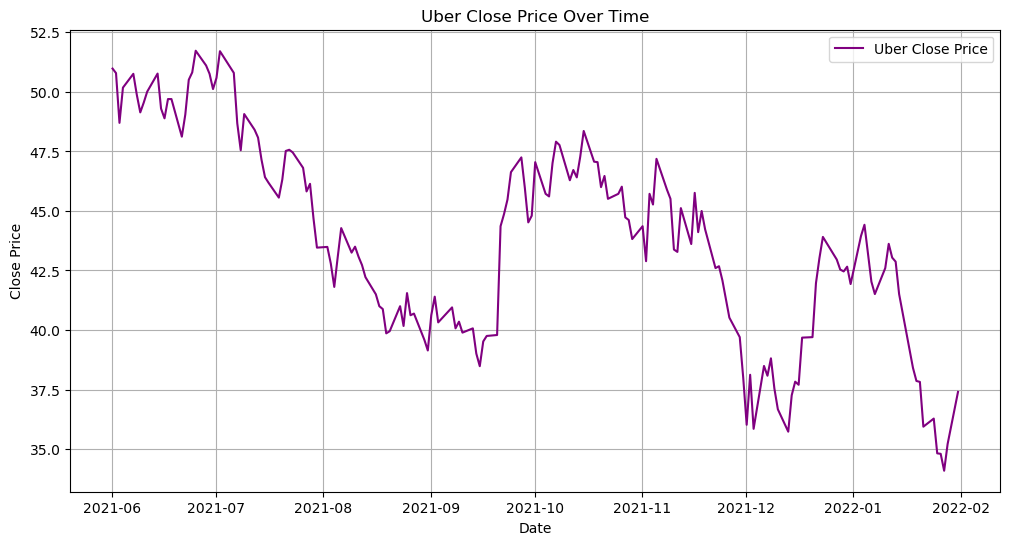

In [106]:
# Convert 'Date' column to datetime
df_uber['Date'] = pd.to_datetime(df_uber['Date'], utc=True).dt.tz_localize(None)

# Set 'Date' as the index (optional but makes plotting easier)
df_uber.set_index('Date', inplace=True)

# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(df_uber.index, df_uber['Close'], color='purple', label='Uber Close Price')
plt.title('Uber Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.legend()
plt.show()

In [107]:
data_uber.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,170.000000,170.000000,170.000000,170.000000,1.700000e+02,170.0,170.0
mean,43.894794,44.673318,43.032441,43.807294,2.506264e+07,0.0,0.0
std,4.279273,4.149631,4.320355,4.231415,1.199509e+07,0.0,0.0
min,34.169998,35.220001,32.810001,34.090000,8.598800e+06,0.0,0.0
25%,40.590001,41.317501,39.895000,40.619999,1.670650e+07,0.0,0.0
50%,44.109999,44.799999,43.295000,43.865000,2.233315e+07,0.0,0.0
75%,47.025001,47.678749,46.257499,47.039999,2.951120e+07,0.0,0.0
max,51.750000,52.360001,50.549999,51.730000,1.066317e+08,0.0,0.0


In [109]:
data_uber.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 170 entries, 2021-06-01 00:00:00-04:00 to 2022-01-31 00:00:00-05:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          170 non-null    float64
 1   High          170 non-null    float64
 2   Low           170 non-null    float64
 3   Close         170 non-null    float64
 4   Volume        170 non-null    int64  
 5   Dividends     170 non-null    float64
 6   Stock Splits  170 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 10.6 KB


In [110]:
data_uber.shape

(170, 7)

In [111]:
data_uber.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [112]:
# Reset index
df_uber.reset_index(inplace=True)

In [113]:
df_uber['Date'] = pd.to_datetime(df_uber['Date'], utc=True).dt.tz_localize(None)

## KPIs

### Completeness

In [114]:
print(f"The missing values in the dataset: {df_uber['Close'].isnull().sum()}")

The missing values in the dataset: 0


No missing values were found, indicating high completeness.

### Latency

In [115]:
min_date = df_uber["Date"].min()
max_date = df_uber["Date"].max()

print(f"Minimum Date: {min_date}")
print(f"Maximum Date: {max_date}")

Minimum Date: 2021-06-01 04:00:00
Maximum Date: 2022-01-31 05:00:00


The data is sourced from Yahoo Finance and represents historical daily prices, which is sufficient for time series analysis and comparison across companies.

### Accuracy

In [116]:
min_close_price = df_uber["Close"].min()
max_close_price = df_uber["Close"].max()

print(f"Minimum Close Price: {min_close_price}")
print(f"Maximum Close Price: {max_close_price}")

Minimum Close Price: 34.09000015258789
Maximum Close Price: 51.72999954223633


The values fall within a realistic range and come from a reliable source, indicating good accuracy.

### Consistency

In [117]:
print("Duplicates:", df_uber.duplicated().sum())
print(df_uber.dtypes)

Duplicates: 0
Date     datetime64[ns]
Close           float64
dtype: object


The dataset has consistent data types (datetime and float) and no duplicate rows, which indicates good consistency.

# 5. ABNB - Airbnb

In [118]:
# ticker
ticker = 'ABNB'

# Create a Ticker object
abnb = yf.Ticker(ticker)

In [119]:
data_abnb = abnb.history(start="2023-11-01", end="2024-04-01", interval="1d")

In [120]:
print(data_abnb.head())

                                 Open        High         Low       Close  \
Date                                                                        
2023-11-01 00:00:00-04:00  118.250000  119.889999  116.660004  119.470001   
2023-11-02 00:00:00-04:00  122.510002  122.739998  114.099998  115.500000   
2023-11-03 00:00:00-04:00  117.980003  123.449997  117.379997  122.639999   
2023-11-06 00:00:00-05:00  123.214996  123.930000  116.849998  118.169998   
2023-11-07 00:00:00-05:00  118.250000  122.180000  118.099998  121.080002   

                             Volume  Dividends  Stock Splits  
Date                                                          
2023-11-01 00:00:00-04:00   9336500        0.0           0.0  
2023-11-02 00:00:00-04:00  14053500        0.0           0.0  
2023-11-03 00:00:00-04:00   9020400        0.0           0.0  
2023-11-06 00:00:00-05:00   7702000        0.0           0.0  
2023-11-07 00:00:00-05:00   5163900        0.0           0.0  


### Extracting closing price columns

In [121]:
# Extract only the closing price column
close_prices = data_abnb["Close"]

df_abnb_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
df_abnb_close.reset_index(drop=True, inplace=True)

print(df_abnb_close.head())

                       Date       Close
0 2023-11-01 00:00:00-04:00  119.470001
1 2023-11-02 00:00:00-04:00  115.500000
2 2023-11-03 00:00:00-04:00  122.639999
3 2023-11-06 00:00:00-05:00  118.169998
4 2023-11-07 00:00:00-05:00  121.080002


### CSV

In [122]:
df_abnb_close.to_csv("abnb_close_prices.csv", index=False)

In [123]:
df_abnb = pd.read_csv("abnb_close_prices.csv")
df_abnb.head()

,Date,Close
0,2023-11-01 00:00:00-04:00,119.470001
1,2023-11-02 00:00:00-04:00,115.500000
2,2023-11-03 00:00:00-04:00,122.639999
3,2023-11-06 00:00:00-05:00,118.169998
4,2023-11-07 00:00:00-05:00,121.080002


### Visualization

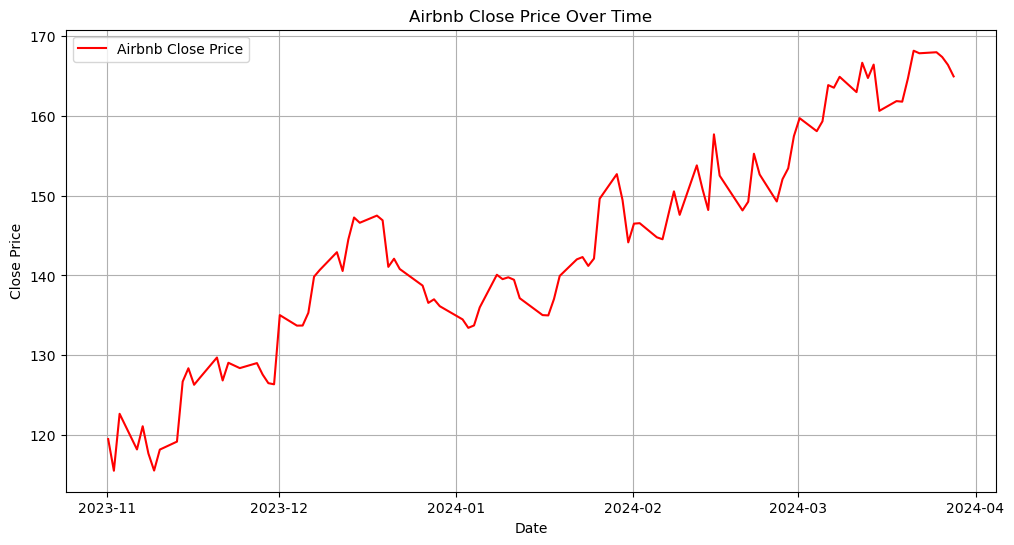

In [124]:
# Convert 'Date' column to datetime
df_abnb['Date'] = pd.to_datetime(df_abnb['Date'], utc=True).dt.tz_localize(None)

# Set 'Date' as the index (optional but makes plotting easier)
df_abnb.set_index('Date', inplace=True)

# Plot the time series
plt.figure(figsize=(12,6))
plt.plot(df_abnb.index, df_abnb['Close'], color='red', label='Airbnb Close Price')
plt.title('Airbnb Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
data_abnb.describe()

In [125]:
data_abnb.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 102 entries, 2023-11-01 00:00:00-04:00 to 2024-03-28 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          102 non-null    float64
 1   High          102 non-null    float64
 2   Low           102 non-null    float64
 3   Close         102 non-null    float64
 4   Volume        102 non-null    int64  
 5   Dividends     102 non-null    float64
 6   Stock Splits  102 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 6.4 KB


In [126]:
data_abnb.shape

(102, 7)

In [127]:
data_abnb.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [128]:
# Reset index
df_abnb.reset_index(inplace=True)

In [129]:
df_abnb['Date'] = pd.to_datetime(df_abnb['Date'], utc=True).dt.tz_localize(None)

## KPIs

### Completeness

In [130]:
print(f"The missing values in the dataset: {df_abnb['Close'].isnull().sum()}")

The missing values in the dataset: 0


No missing values were found, indicating high completeness.

### Latency

In [132]:
min_date = df_abnb["Date"].min()
max_date = df_abnb["Date"].max()

print(f"Minimum Date: {min_date}")
print(f"Maximum Date: {max_date}")

Minimum Date: 2023-11-01 04:00:00
Maximum Date: 2024-03-28 04:00:00


The data is sourced from Yahoo Finance and represents historical daily prices, which is sufficient for time series analysis and comparison across companies.

### Accuracy

In [133]:
min_close_price = df_abnb["Close"].min()
max_close_price = df_abnb["Close"].max()

print(f"Minimum Close Price: {min_close_price}")
print(f"Maximum Close Price: {max_close_price}")

Minimum Close Price: 115.5
Maximum Close Price: 168.17999267578125


The values fall within a realistic range and come from a reliable source, indicating good accuracy.

### Consistency

In [134]:
print("Duplicates:", df_abnb.duplicated().sum())
print(df_abnb.dtypes)

Duplicates: 0
Date     datetime64[ns]
Close           float64
dtype: object


The dataset has consistent data types (datetime and float) and no duplicate rows, which indicates good consistency.

## Final takeaway

All datasets were complete, consistent, and accurate, with no missing values or duplicate records. The data sourced from Yahoo Finance provided reliable historical daily prices, making it suitable for time series analysis and cross-company comparison.

The analysis revealed clear differences in stock behavior across companies. Moderna (MRNA) exhibited the highest volatility, while Palantir (PLTR) and Shopify (SHOP) showed stronger growth dynamics. Uber (UBER) and Airbnb (ABNB) demonstrated moderate fluctuations, reflecting their position in competitive platform-based markets.

Overall, the project highlights how different industries and business models influence stock price movements, which is essential for understanding market dynamics and making informed investment decisions.